### Simple Polynomial Regression

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
X = 6 * np.random.rand(200,1) - 3
Y = 0.8 * X ** 2 + 0.9 * X + 2 + np.random.randn(200,1)

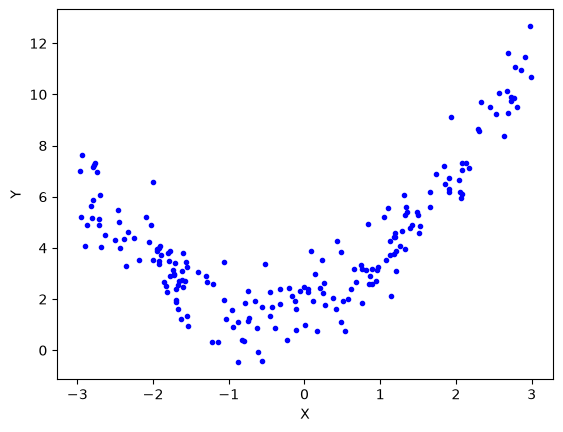

In [5]:
plt.plot(X,Y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [10]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,42)

In [11]:
lr = LinearRegression()
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.74]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[4.16]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[21.19]


In [12]:
Y_pred = lr.predict(X_test)
r2_score(Y_test,Y_pred)

0.16521292120894548

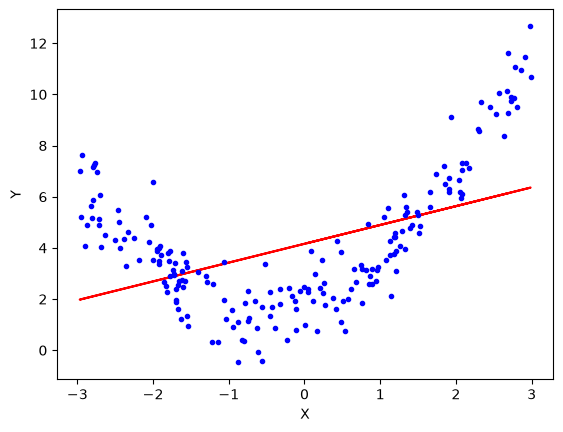

In [13]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,Y,"b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [18]:
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)

In [19]:
print(X_train[0])
print(X_train_trans[0])

[2.69299354]
[1.         2.69299354 7.25221419]


In [20]:
lr = LinearRegression()
lr.fit(X_train_trans,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[0. ,0.88,0.8 ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.9]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[33.46,20.95, 0. ]"


In [21]:
Y_pred_trans = lr.predict(X_test_trans)
r2_score(Y_test,Y_pred_trans)

0.8872118357060872

In [23]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.88456763 0.80456708]]
[1.90225092]


In [24]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
Y_new = lr.predict(X_new_poly)

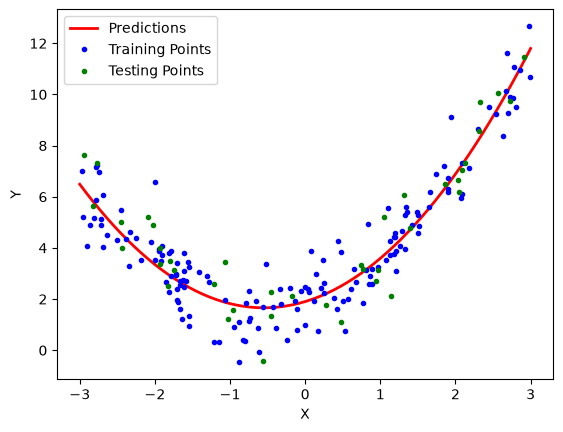

In [26]:
plt.plot(X_new,Y_new,"r-",linewidth=2,label="Predictions")
plt.plot(X_train,Y_train,"b.",label='Training Points')
plt.plot(X_test,Y_test,"g.",label='Testing Points')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [27]:
def polynomial_regression(degree):
    X_new = np.linspace(-3,3,100).reshape(100,1)
    X_new_trans = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree,include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features",polybig_features),
        ("std_scaler",std_scaler),
        ("Lin_Reg",lin_reg)
    ])
    polynomial_regression.fit(X,Y)
    Y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new,Y_newbig,'r',label='Degree'+ str(degree) , linewidth=2)
    plt.plot(X_train,Y_train,'b.',linewidth=3)
    plt.plot(X_test,Y_test,'g.',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis([-3,3,0,10])
    plt.show()

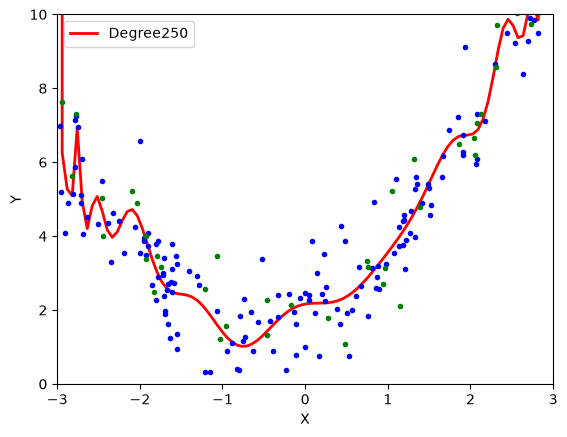

In [36]:
polynomial_regression(250)

### Multiple Polynomial Regression

In [37]:
X = 7 * np.random.rand(100,1) - 2.8
Y = 7 * np.random.rand(100,1) - 2.8
Z = X ** 2 + Y ** 2 + 0.2 * X + 0.2 * Y + 0.1 * X * Y + 2 + np.random.randn(100,1)

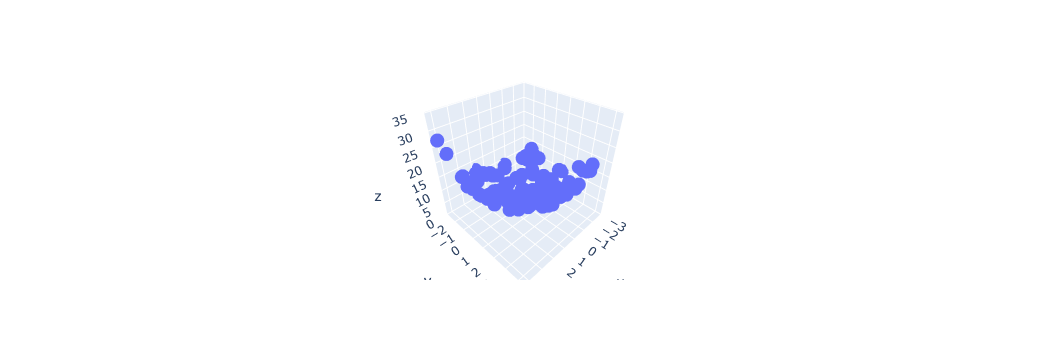

In [38]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=X.ravel(),y=Y.ravel(),z=Z.ravel())
fig.show()

In [39]:
lr = LinearRegression()
lr.fit(np.array([X,Y]).reshape(100,2),Z)
X_inp = np.linspace(X.min(),X.max(),10)
Y_inp = np.linspace(Y.min(),Y.max(),10)
xGrid , yGrid = np.meshgrid(X_inp,Y_inp)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
Z_final = lr.predict(final).reshape(10,10)

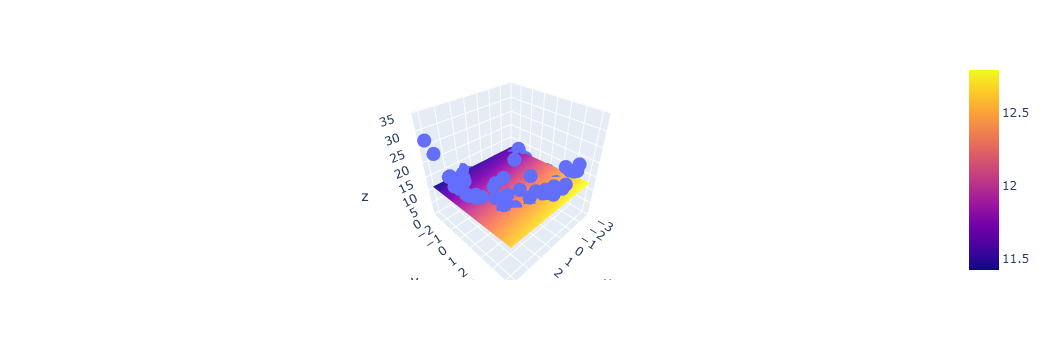

In [41]:
import plotly.graph_objects as go
fig = px.scatter_3d(df,x=X.ravel(),y=Y.ravel(),z=Z.ravel())
fig.add_trace(go.Surface(x=X_inp,y=Y_inp,z=Z_final))
fig.show()

In [42]:
X_multi = np.array([X,Y]).reshape(100,2)
X_multi.shape

(100, 2)

In [53]:
poly = PolynomialFeatures(degree=6)
X_multi_trans = poly.fit_transform(X_multi)

In [46]:
?poly

Type:        PolynomialFeatures
String form: PolynomialFeatures()
File:        c:\users\anjli kumari\anaconda3\envs\machine_learning\lib\site-packages\sklearn\preprocessing\_polynomial.py
Docstring:  
Generate polynomial and interaction features.

Generate a new feature matrix consisting of all polynomial combinations
of the features with degree less than or equal to the specified degree.
For example, if an input sample is two dimensional and of the form
[a, b], the degree-2 polynomial features are [1, a, b, a^2, ab, b^2].

Read more in the :ref:`User Guide <polynomial_features>`.

Parameters
----------
degree : int or tuple (min_degree, max_degree), default=2
    If a single int is given, it specifies the maximal degree of the
    polynomial features. If a tuple `(min_degree, max_degree)` is passed,
    then `min_degree` is the minimum and `max_degree` is the maximum
    polynomial degree of the generated features. Note that `min_degree=0`
    and `min_degree=1` are equivalent as outp

In [54]:
print("Input:",poly.n_features_in_)
print("Output:",poly.n_output_features_)
print("Powers:",poly.powers_)

Input: 2
Output: 28
Powers: [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]
 [4 0]
 [3 1]
 [2 2]
 [1 3]
 [0 4]
 [5 0]
 [4 1]
 [3 2]
 [2 3]
 [1 4]
 [0 5]
 [6 0]
 [5 1]
 [4 2]
 [3 3]
 [2 4]
 [1 5]
 [0 6]]


In [55]:
X_multi_trans.shape

(100, 28)

In [56]:
lr = LinearRegression()
lr.fit(X_multi_trans,Z)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 28)","[[-0. ,-4.95,-0.39,..., 0.01, 0.05, 0.02]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[15.25]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(27)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](28,)","[12887.05,10707.19, 9056.86,..., 2.67, 2.21, 0. ]"


In [57]:
X_test_multi = poly.fit_transform(final)

In [58]:
Z_final = lr.predict(X_multi_trans).reshape(10,10)

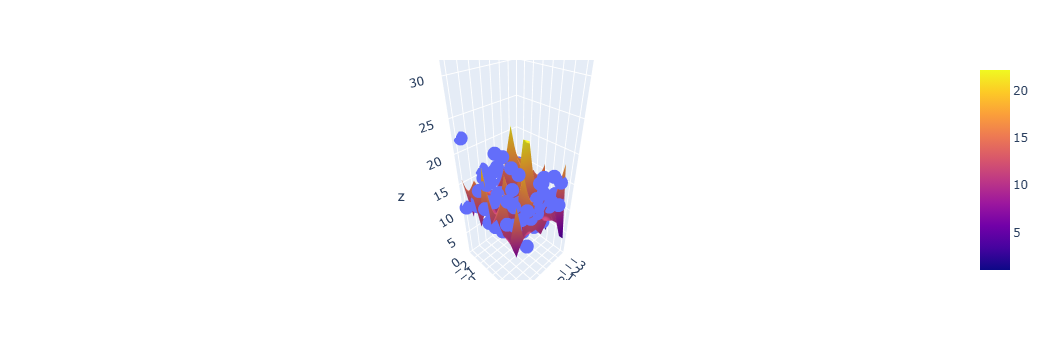

In [59]:
fig = px.scatter_3d(x=X.ravel(),y=Y.ravel(),z=Z_final.ravel())
fig.add_trace(go.Surface(x=X_inp,y=Y_inp,z=Z_final))
fig.update_layout(scene=dict(zaxis=dict(range=[0,35])))
fig.show()